In [32]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [33]:
# load data
downloads = pd.read_csv("dataset/downloads.csv")
members = pd.read_csv("dataset/members.csv")

In [34]:
# overview of downloads
downloads.head()

,uid,supplier,image_id,res,dlType,date_download,dlyear,dlmonth,dlday,fraud,file_type
0,e98a4c15-2cb5-4ed1-b57f-30371300fd5f,8107867a-1f4a-4035-9c1d-8ed03d2ec2cd,197093672,mega,3,2024-09-30 23:59:55,2024,9,30,0,0
1,10870f27-fe41-4bae-8ed4-f93ee45210e8,76d62316-3394-4824-aa2b-117cc6f0ca83,16357128,NaN,2,2024-09-30 23:59:49,2024,9,30,0,1
2,79b326f5-eab7-4f18-92c2-608c184ace1d,4a160b61-23e1-42ef-b59a-4ea253f504bc,46529682,NaN,5,2024-09-30 23:59:41,2024,9,30,0,1
3,25267a99-0c27-49f9-bb8f-37c3359aeb21,da46eaba-d7ac-4c8a-9c40-ae0e46e68d08,84208353,NaN,5,2024-09-30 23:59:38,2024,9,30,0,1
4,6515c23b-31ea-429e-a9f1-135cc4afcf3a,b3287ba9-40d6-4cfc-95d9-e4fd840889f1,174899950,med,3,2024-09-30 23:59:34,2024,9,30,0,0


In [35]:
# overview of members
members.head()

,uid,date_register,country,contributor
0,c116eaf6-adae-4695-9dbc-f416e16bf9fd,2005-06-01,KR,1
1,88dcad39-de41-4193-a31a-406cefb2e5fa,2005-06-01,CA,1
2,a7cc4e9e-9e9a-4682-862f-7ba8776c10d4,2005-06-06,FX,1
3,0937ff63-d59a-44f3-bcb9-0ec34f38aebf,2005-06-06,RU,1
4,c0579051-41bd-4629-9ab3-1e149da03c05,2005-06-06,ZA,1


In [36]:
# check total number of uid in members that are not in downloads
uid_not_in_downloads = members[~members['uid'].isin(downloads['uid'])]
total_uid_not_in_downloads = uid_not_in_downloads['uid'].count()

print(f"number of uid in members that are not in downloads: {total_uid_not_in_downloads}")

number of uid in members that are not in downloads: 67859


In [37]:
# merge downloads and members data based on uid
data = pd.merge(downloads, members, on = "uid", how = "left")

# convert date columns to datetime for easier filtering
data['date_download'] = pd.to_datetime(data['date_download'])
data['date_register'] = pd.to_datetime(data['date_register'])

data.head()

,uid,supplier,image_id,res,dlType,date_download,dlyear,dlmonth,dlday,fraud,file_type,date_register,country,contributor
0,e98a4c15-2cb5-4ed1-b57f-30371300fd5f,8107867a-1f4a-4035-9c1d-8ed03d2ec2cd,197093672,mega,3,2024-09-30 23:59:55,2024,9,30,0,0,2021-08-16,TW,0
1,10870f27-fe41-4bae-8ed4-f93ee45210e8,76d62316-3394-4824-aa2b-117cc6f0ca83,16357128,NaN,2,2024-09-30 23:59:49,2024,9,30,0,1,2020-02-07,TH,0
2,79b326f5-eab7-4f18-92c2-608c184ace1d,4a160b61-23e1-42ef-b59a-4ea253f504bc,46529682,NaN,5,2024-09-30 23:59:41,2024,9,30,0,1,2013-05-06,KR,0
3,25267a99-0c27-49f9-bb8f-37c3359aeb21,da46eaba-d7ac-4c8a-9c40-ae0e46e68d08,84208353,NaN,5,2024-09-30 23:59:38,2024,9,30,0,1,2013-03-27,US,0
4,6515c23b-31ea-429e-a9f1-135cc4afcf3a,b3287ba9-40d6-4cfc-95d9-e4fd840889f1,174899950,med,3,2024-09-30 23:59:34,2024,9,30,0,0,2012-06-18,HK,0


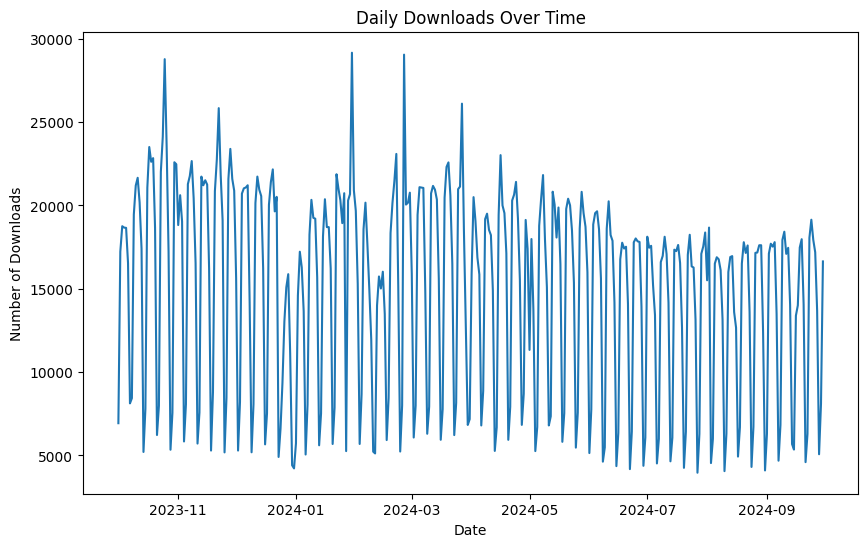

In [38]:
# aggregate downloads by day
daily_downloads = data.groupby(data['date_download'].dt.date).size()
daily_downloads = daily_downloads.sort_index()

# plot daily downloads
plt.figure(figsize = (10, 6))
daily_downloads.plot(title = "Daily Downloads Over Time")
plt.ylabel("Number of Downloads")
plt.xlabel("Date")
plt.show()

In [39]:
# calculate the difference between consecutive days
daily_downloads_diff = daily_downloads.diff()

# identify drops (negative values)
drops = daily_downloads_diff[daily_downloads_diff < 0]

# initialize a list to store the results
drop_info = []

# for each drop, find the day after where the downloads start increasing
for drop_date in drops.index:
    if len(drop_info) != 0:
        if drop_date < drop_info[-1]["recovery_date"]:
            continue

    drop_value = drops[drop_date]

    # find recovery date
    recovery_date = daily_downloads_diff[drop_date:].gt(0).idxmax()

    # identify the biggest drop within the drop and recovery period
    drop_position = daily_downloads.index.get_loc(drop_date)
    recovery_date_position = daily_downloads.index.get_loc(recovery_date)
    previous_drop_date = daily_downloads.index[drop_position - 1]
    previous_drop_value = daily_downloads.iloc[drop_position - 1]
    previous_recovery_date = daily_downloads.index[recovery_date_position - 1]
    drop_period = daily_downloads[drop_date:previous_recovery_date]
    # drop_period = daily_downloads[drop_date:recovery_date - pd.Timedelta(days = 1)]
    biggest_drop_value = drop_period.min()
    biggest_drop_date = drop_period.idxmin() # get the date of the biggest drop

    drop_info.append({
        "before_start_drop_date": previous_drop_date,
        "before_start_drop_value": previous_drop_value,
        "start_drop_date": drop_date,
        "start_drop_value": daily_downloads[drop_date],
        "recovery_date": recovery_date,
        "recovery_date_value": daily_downloads[recovery_date],
        "biggest_drop_date": biggest_drop_date,
        "biggest_drop_value": daily_downloads[biggest_drop_date]
    })

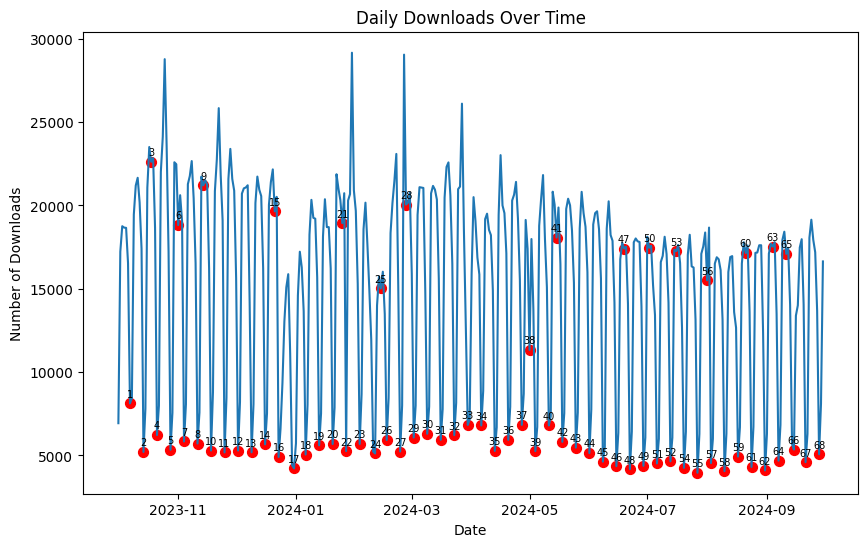

In [40]:
plt.figure(figsize = (10, 6))
daily_downloads.plot(title = "Daily Downloads Over Time")
plt.ylabel("Number of Downloads")
plt.xlabel("Date")

# counter to number the annotations
counter = 1

for drop in drop_info:
    plt.scatter(drop['biggest_drop_date'], drop['biggest_drop_value'], 
        color = 'red', s = 50)
    
    # add text annotation
    plt.text(drop['biggest_drop_date'], drop['biggest_drop_value'] + 250, 
             str(counter), color = 'black', fontsize = 7, ha = 'center', va = 'bottom')

    counter += 1

plt.show()

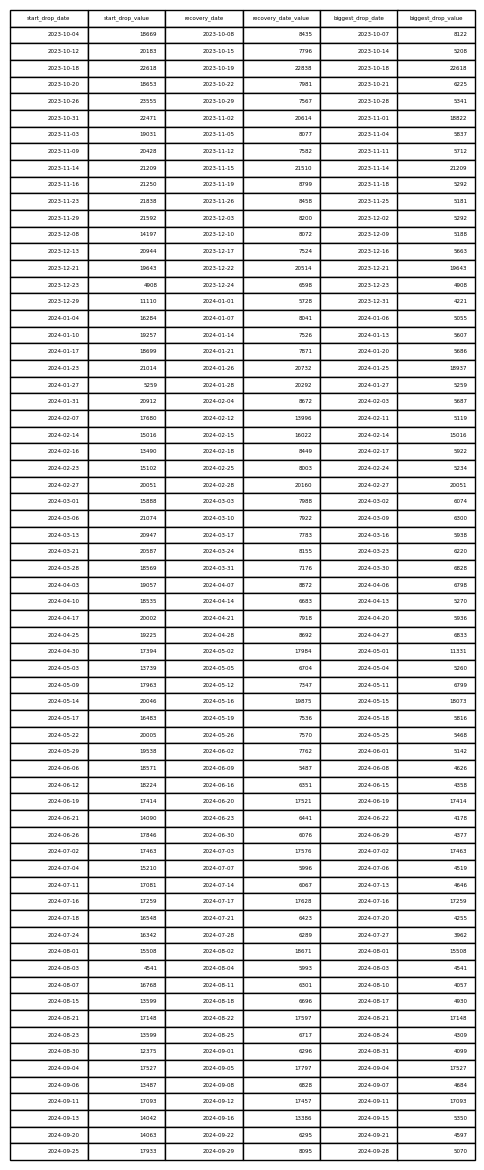

In [47]:
# converting list of dictionaries to a dataframe
drop_info_df = pd.DataFrame(drop_info)
drop_info_overall_df = drop_info_df[[col for col in drop_info_df.columns if col not in ['before_start_drop_date', 'before_start_drop_value']]]

# plot the dataframe as a table
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=drop_info_overall_df.values, colLabels=drop_info_overall_df.columns, loc='center')

# save as an image
plt.savefig("images/overall_drop_table.png", dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# find the entry with the biggest drop value
min_drop_entry = min(drop_info, key = lambda x: x['biggest_drop_value'])

print(f"the biggest drop value is {min_drop_entry['biggest_drop_value']} on {min_drop_entry['biggest_drop_date']}")

the biggest drop value is 3962 on 2024-07-27


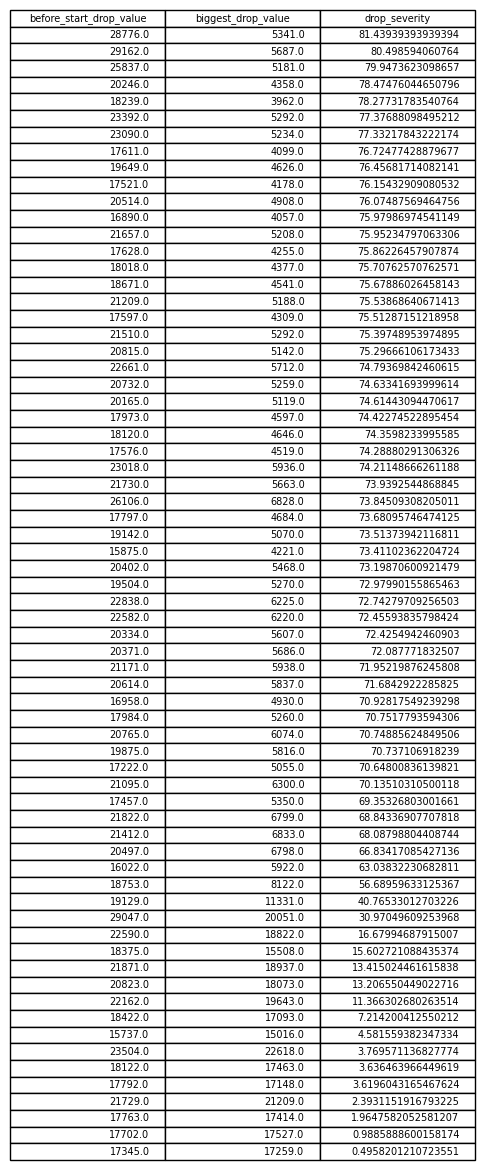

In [54]:
# drop severity (percentage drop)
drop_info_df['drop_severity'] = (drop_info_df['before_start_drop_value'] - drop_info_df['biggest_drop_value']) / drop_info_df['before_start_drop_value'] * 100

percentage_drop_df = drop_info_df[['before_start_drop_value', 'biggest_drop_value', 'drop_severity']]
percentage_drop_df = percentage_drop_df.sort_values(by='drop_severity', ascending=False)

# plot the dataframe as a table
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=percentage_drop_df.values, colLabels=percentage_drop_df.columns, loc='center')

# save as an image
plt.savefig("images/percentage_drop_table.png", dpi=300, bbox_inches='tight')
plt.show()

c:\Users\tellw\anaconda3\envs\llm\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


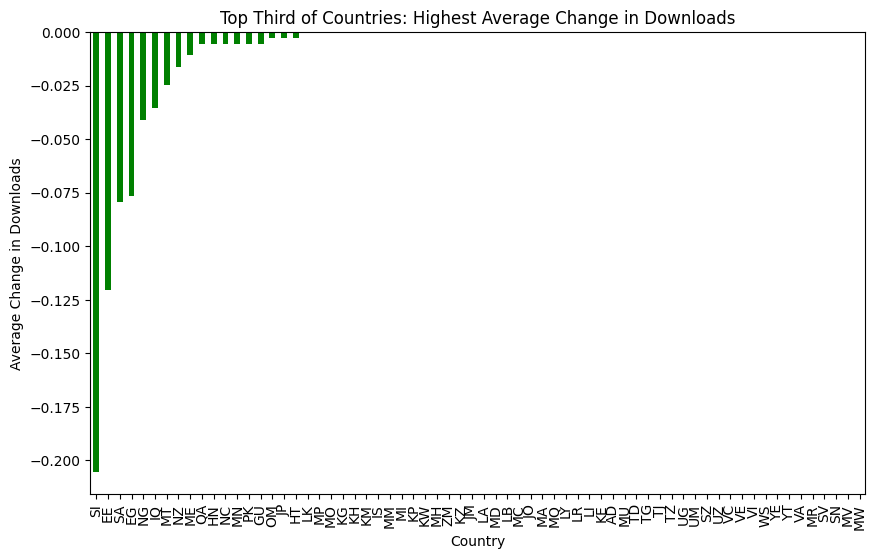

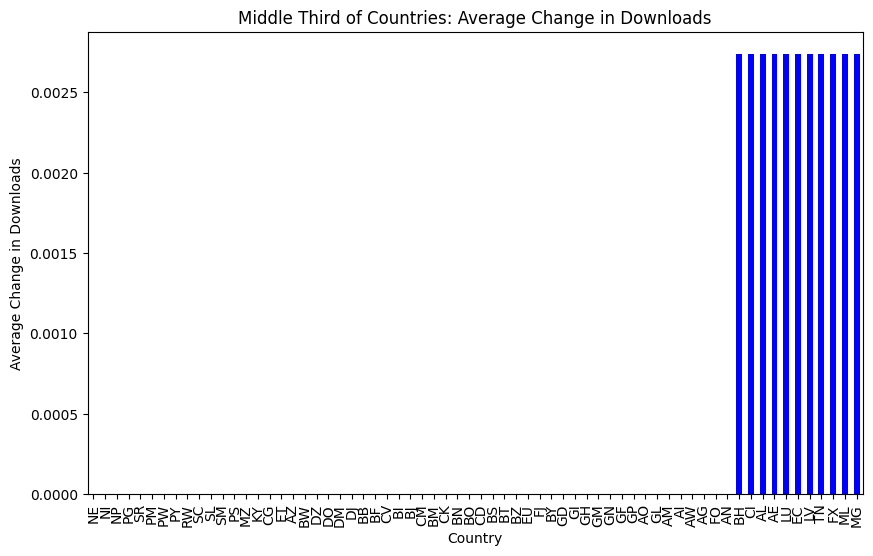

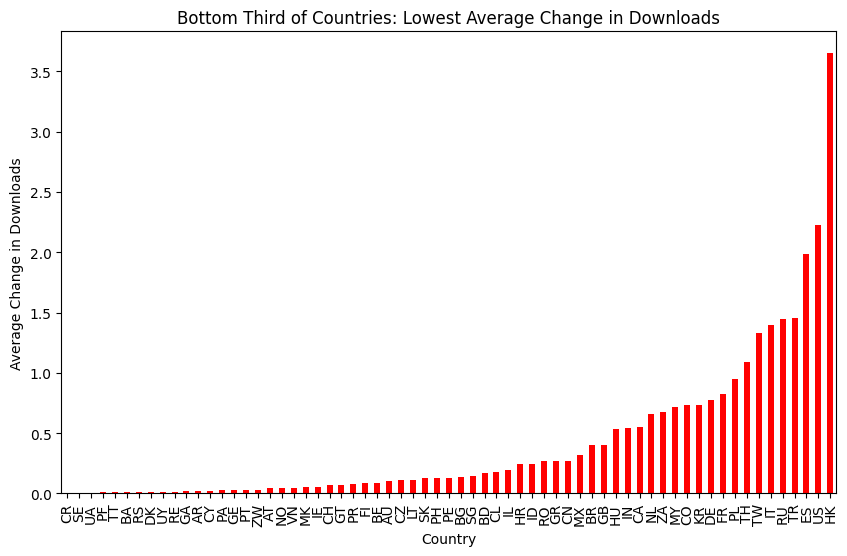

In [43]:
# group by country and calculate changes in downloads
country_trends = data.groupby(['country', data['date_download'].dt.date]).size().unstack(fill_value = 0)
country_changes = country_trends.diff(axis = 1).mean(axis = 1).sort_values()

split_size = len(country_changes) // 3
splits = np.array_split(country_changes, 3)

top_third = splits[0]
middle_third = splits[1]
bottom_third = splits[2]

# plot the top third
plt.figure(figsize = (10, 6))
top_third.plot(kind = "bar", color = 'green', title = "Top Third of Countries: Highest Average Change in Downloads")
plt.ylabel("Average Change in Downloads")
plt.xlabel("Country")
plt.show()

# plot the middle third
plt.figure(figsize = (10, 6))
middle_third.plot(kind = "bar", color = 'blue', title = "Middle Third of Countries: Average Change in Downloads")
plt.ylabel("Average Change in Downloads")
plt.xlabel("Country")
plt.show()

# plot the bottom third (lowest average change)
plt.figure(figsize = (10, 6))
bottom_third.plot(kind = "bar", color = 'red', title = "Bottom Third of Countries: Lowest Average Change in Downloads")
plt.ylabel("Average Change in Downloads")
plt.xlabel("Country")
plt.show()

In [44]:
user_trends = data.groupby(['uid', data['date_download'].dt.date]).size().unstack(fill_value = 0)
user_changes = user_trends.diff(axis = 1).sum(axis = 1).sort_values()
user_changes

uid
070894ee-b95b-420c-b04c-5fb9b213a2c6    -100.0
71fd4514-eb3e-4b93-a057-d183973c724a    -100.0
e9faee96-f3e1-4b8a-9147-063230b8d407    -100.0
42982fe8-a14d-4a35-b3b7-bfdb5f5f464c    -100.0
c477080d-ab5c-4054-bac4-3ea2f5ca9696    -100.0
                                         ...  
f22e8cfb-3213-4796-9489-3b2617aa4c9f     100.0
5e89fad3-0f5b-4942-84e7-b4d8577f6c1c     114.0
a84e8d2e-e56d-4510-bf1f-c461647c47cc     130.0
ae534d33-33be-483c-8210-a43320e0a90a     166.0
694979d0-7c6c-460f-b672-ab4753b98dd1    1028.0
Length: 84841, dtype: float64

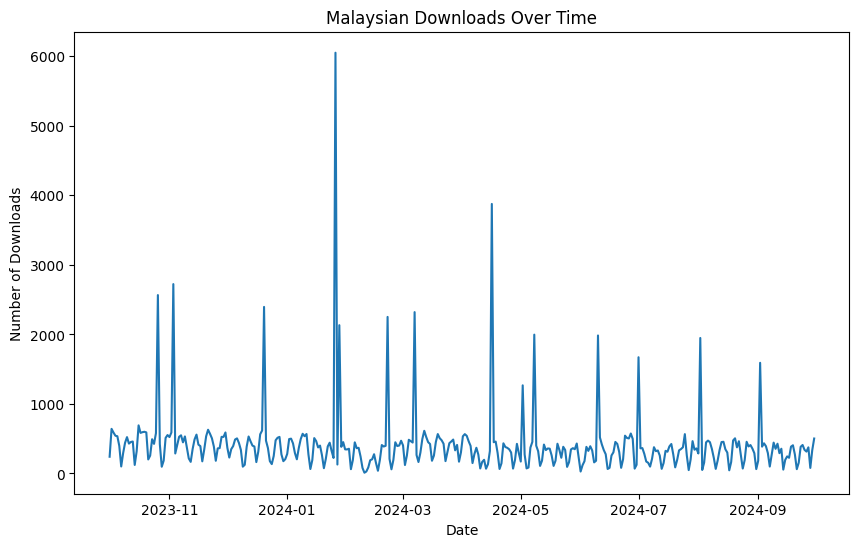

In [45]:
# filter data for Malaysia
malaysia_data = data[data['country'] == 'MY']
malaysia_trends = malaysia_data.groupby(malaysia_data['date_download'].dt.date).size()

# plot Malaysian downloads
plt.figure(figsize = (10, 6))
malaysia_trends.plot(title = "Malaysian Downloads Over Time")
plt.ylabel("Number of Downloads")
plt.xlabel("Date")
plt.show()

In [46]:
# assuming a CSV file 'malaysia_holidays.csv' exists with a 'date' column
malaysia_holidays = pd.read_csv("malaysia_holidays.csv")
malaysia_holidays['date'] = pd.to_datetime(malaysia_holidays['date'])

# compare download patterns on public holidays vs non-holidays
malaysia_data['is_holiday'] = malaysia_data['date_download'].dt.date.isin(malaysia_holidays['date'].dt.date)
holiday_downloads = malaysia_data.groupby('is_holiday').size()
print(holiday_downloads)


FileNotFoundError: [Errno 2] No such file or directory: 'malaysia_holidays.csv'

In [ ]:
# categorize users by their download activity
user_download_counts = data['uid'].value_counts()
major_downloaders = user_download_counts[user_download_counts > 50].sum()
small_downloaders = user_download_counts[user_download_counts <= 50].sum()

print(f"Downloads by major downloaders: {major_downloaders}")
print(f"Downloads by small downloaders: {small_downloaders}")


In [ ]:
# analyze fraud patterns
fraud_count = data['fraud'].value_counts()
print(f"Fraud Counts: \n{fraud_count}")

# analyze supplier impact
supplier_trends = data.groupby(['supplier', data['date_download'].dt.date]).size().unstack(fill_value = 0)
supplier_changes = supplier_trends.diff(axis = 1).mean(axis=1).sort_values()

plt.figure(figsize = (10, 6))
supplier_changes.plot(kind = "bar", title = "Average Change in Downloads by Supplier")
plt.ylabel("Average Change in Downloads")
plt.xlabel("Supplier")
plt.show()

Fraud Counts: 
fraud
0    5460260
Name: count, dtype: int64
